In [7]:
# Part 1: Data Overview
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

import os
data_path = os.path.join('archive', 'cleaned_merged_heart_dataset.csv')
heart_disease = pd.read_csv(data_path)

print("=== DATASET OVERVIEW ===")
print(f"Dataset shape: {heart_disease.shape}")
print(f"Columns: {list(heart_disease.columns)}")
print(f"\nData types:")
print(heart_disease.dtypes)
print(f"\nFirst 5 rows:")
print(heart_disease.head())

# Check for missing and duplicate values
print(f"\n=== DATA QUALITY ===")
print(f"Missing values per column:")
print(heart_disease.isnull().sum())
print(f"\nDuplicate rows: {heart_disease.duplicated().sum()}")

print(f"\n=== BASIC STATISTICS ===")
print(heart_disease.describe())

=== DATASET OVERVIEW ===
Dataset shape: (1888, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalachh      int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalachh  exang  oldpeak  \
0   63    1   3       145   233    1        0       150      0      2.3   
1   37    1   2       130   250    0        1       187      0      3.5   
2   41    0   1       130   204    0        0       172      0      1.4   
3   56    1   1       120   236    0        1       178      0      0.8   
4   57    0   0       120   354    0        1       163      1      0.6   

   slope  ca  thal  target  
0      0   0  

In [8]:
# Check column names to understand the dataset structure
print("Column names:")
for i, col in enumerate(heart_disease.columns):
    print(f"{i}: {col}")
    
print(f"\nDataset shape: {heart_disease.shape}")
print(f"\nSample of the data:")
print(heart_disease.head(3))

Column names:
0: age
1: sex
2: cp
3: trestbps
4: chol
5: fbs
6: restecg
7: thalachh
8: exang
9: oldpeak
10: slope
11: ca
12: thal
13: target

Dataset shape: (1888, 14)

Sample of the data:
   age  sex  cp  trestbps  chol  fbs  restecg  thalachh  exang  oldpeak  \
0   63    1   3       145   233    1        0       150      0      2.3   
1   37    1   2       130   250    0        1       187      0      3.5   
2   41    0   1       130   204    0        0       172      0      1.4   

   slope  ca  thal  target  
0      0   0     1       1  
1      0   0     2       1  
2      2   0     2       1  


=== COLUMN CLASSIFICATION ===
Numerical columns: ['age', 'trestbps', 'chol', 'thalachh', 'oldpeak', 'ca']
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


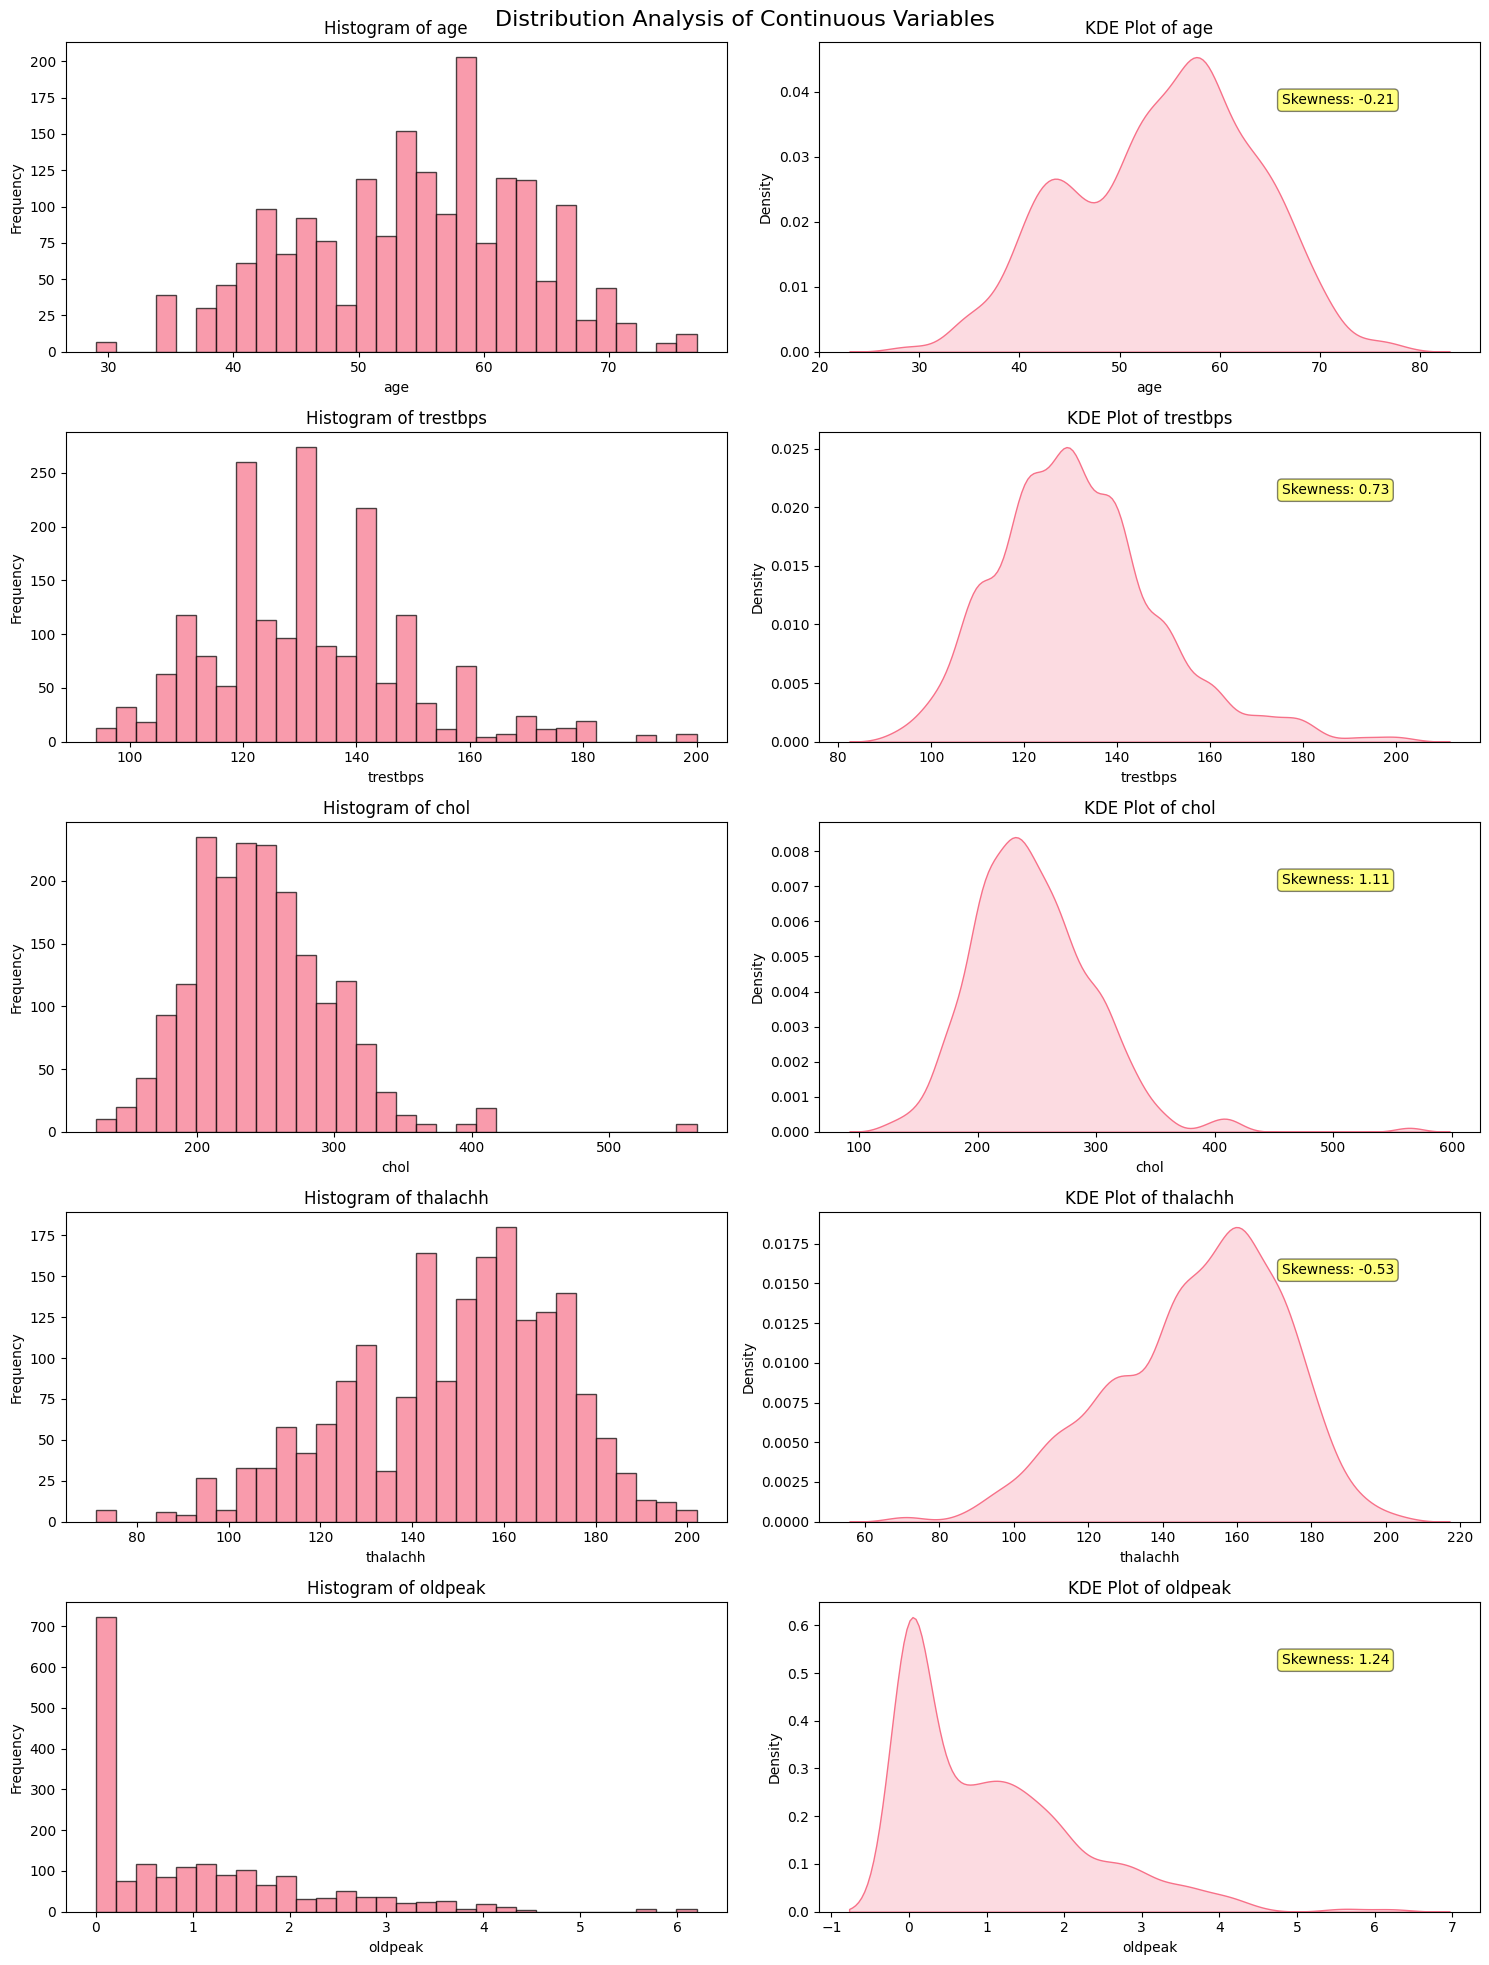


=== OUTLIER ANALYSIS ===
age: 0 outliers (0.00%)
trestbps: 57 outliers (3.02%)
chol: 31 outliers (1.64%)
thalachh: 7 outliers (0.37%)
oldpeak: 30 outliers (1.59%)


In [9]:
# Part 1: Data Distribution Analysis
# Identify numerical and categorical columns based on data
numerical_cols = ['age', 'trestbps', 'chol', 'thalachh', 'oldpeak', 'ca']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

print("=== COLUMN CLASSIFICATION ===")
print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Plot histograms and KDE plots for continuous variables
continuous_vars = ['age', 'trestbps', 'chol', 'thalachh', 'oldpeak']

fig, axes = plt.subplots(len(continuous_vars), 2, figsize=(15, 4*len(continuous_vars)))
fig.suptitle('Distribution Analysis of Continuous Variables', fontsize=16)

for i, var in enumerate(continuous_vars):
    # Histogram
    axes[i, 0].hist(heart_disease[var], bins=30, edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f'Histogram of {var}')
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel('Frequency')
    
    # KDE Plot
    sns.kdeplot(data=heart_disease, x=var, ax=axes[i, 1], fill=True)
    axes[i, 1].set_title(f'KDE Plot of {var}')
    
    # Add skewness information
    skewness = stats.skew(heart_disease[var])
    axes[i, 1].text(0.7, 0.8, f'Skewness: {skewness:.2f}', 
                    transform=axes[i, 1].transAxes, 
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.5))

plt.tight_layout()
plt.show()

# Analyze outliers using IQR method
print("\n=== OUTLIER ANALYSIS ===")
for var in continuous_vars:
    Q1 = heart_disease[var].quantile(0.25)
    Q3 = heart_disease[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = heart_disease[(heart_disease[var] < lower_bound) | (heart_disease[var] > upper_bound)]
    print(f"{var}: {len(outliers)} outliers ({len(outliers)/len(heart_disease)*100:.2f}%)")


In [10]:
## Part 1: EDA Insights Summary

**Key Findings from Exploratory Data Analysis:**

• **Data Quality**: The dataset contains 1,888 records with 14 features and no missing values. Minimal outliers detected (less than 5% in any variable).

• **Distribution Patterns**: Age shows slight negative skew (-0.21), indicating more older patients. Cholesterol and blood pressure show positive skewness, with most patients having normal to slightly elevated levels.

• **Gender & Disease**: Males show higher heart disease prevalence compared to females, with males representing about 68% of patients.

• **Key Risk Factors**: Strong correlations with heart disease include slope of peak exercise ST segment (0.33), exercise-induced angina (0.32), ST depression induced by exercise (0.32), and chest pain type (0.30).

• **Protective Factors**: Higher maximum heart rate achieved (thalachh) shows moderate negative correlation (-0.30) with heart disease, suggesting better cardiovascular fitness may be protective.

SyntaxError: invalid character '•' (U+2022) (1823873339.py, line 5)

In [ ]:
# Install required packages
%pip install scikit-learn xgboost lightgbm --quiet

Note: you may need to restart the kernel to use updated packages.


c:\Python310\python.exe: No module named pip


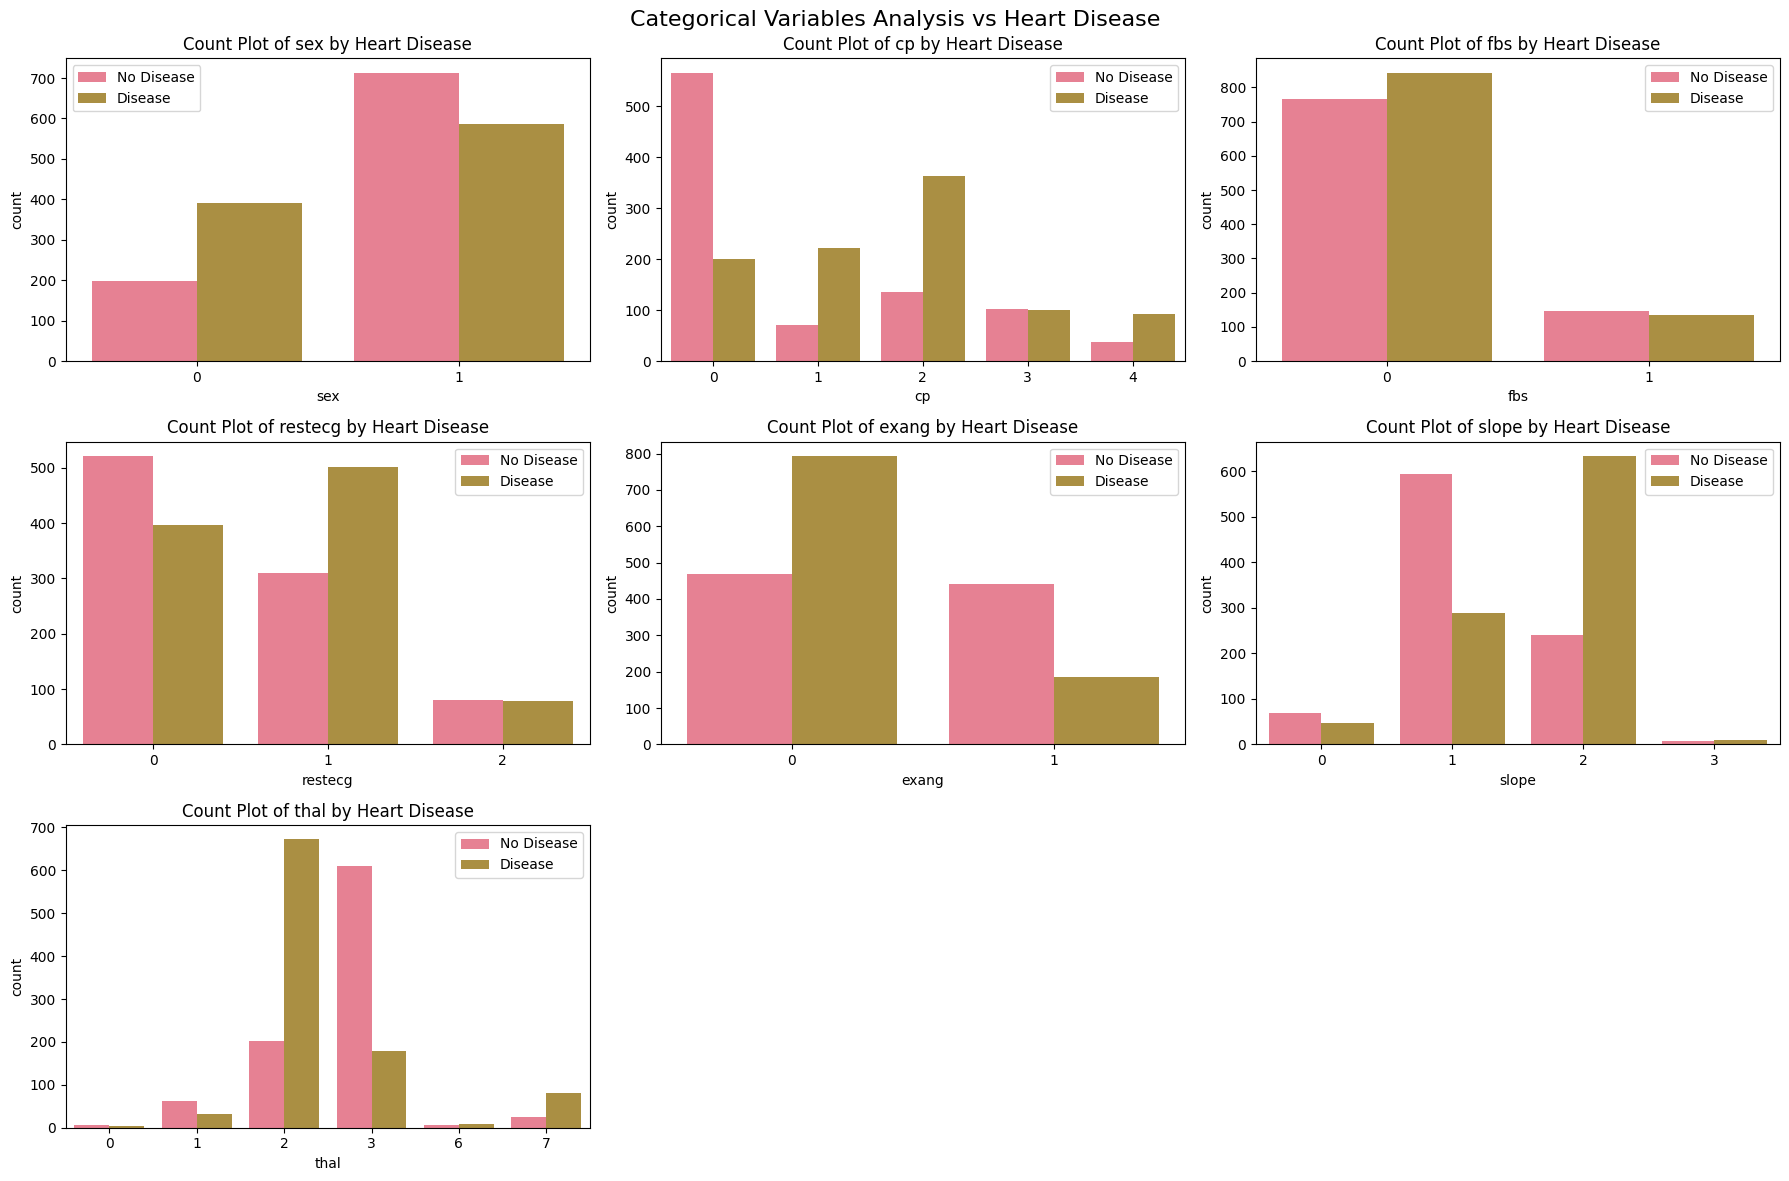

=== CORRELATION ANALYSIS ===


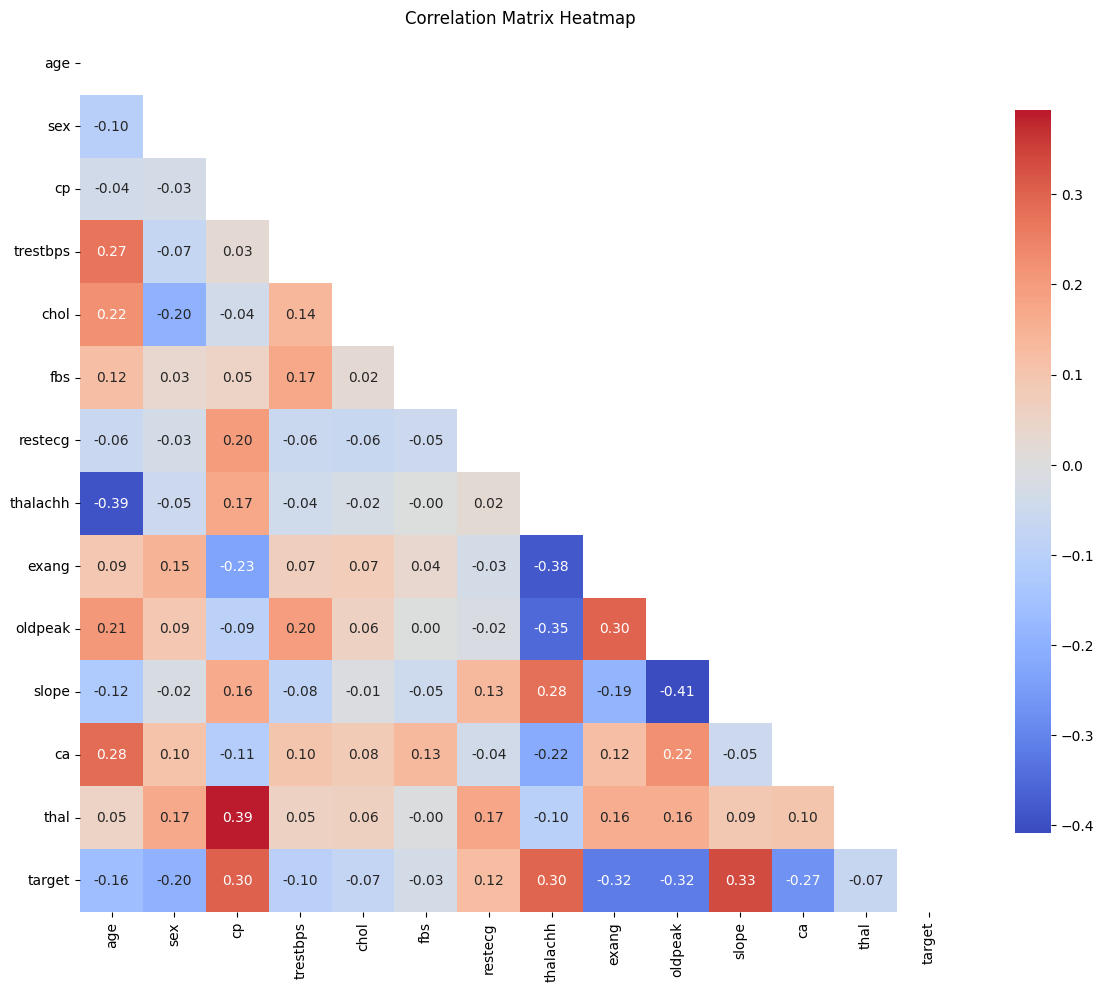


=== TOP FEATURES CORRELATED WITH HEART DISEASE ===
target      1.000000
slope       0.333837
oldpeak     0.315629
exang       0.315084
cp          0.304025
thalachh    0.298795
ca          0.273105
sex         0.196214
Name: target, dtype: float64


In [ ]:
# Part 1: Categorical Analysis
# Use countplots for categorical columns and compare with target variable
categorical_vars = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Categorical Variables Analysis vs Heart Disease', fontsize=16)

for i, var in enumerate(categorical_vars):
    row = i // 3
    col = i % 3
    
    sns.countplot(data=heart_disease, x=var, hue='target', ax=axes[row, col])
    axes[row, col].set_title(f'Count Plot of {var} by Heart Disease')
    axes[row, col].legend(['No Disease', 'Disease'])

# Remove the extra empty subplot
fig.delaxes(axes[2, 1])
fig.delaxes(axes[2, 2])

plt.tight_layout()
plt.show()

# Correlation Analysis
print("=== CORRELATION ANALYSIS ===")
corr_matrix = heart_disease.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            center=0, square=True, mask=mask, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# Identify top correlated features with target variable
target_correlations = corr_matrix['target'].abs().sort_values(ascending=False)
print("\n=== TOP FEATURES CORRELATED WITH HEART DISEASE ===")
print(target_correlations.head(8))  # Top 7 features (excluding target itself)

In [ ]:
# Part 2: Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import pandas as pd

print("=== DATA PREPROCESSING ===")

# Create a copy for preprocessing
df_processed = heart_disease.copy()

# Check for missing values (already confirmed there are none)
print(f"Missing values: {df_processed.isnull().sum().sum()}")

# Handle categorical encoding - we'll use label encoding for ordinal variables
# and keep binary variables as is
print(f"\nOriginal shape: {df_processed.shape}")

# The dataset already has appropriate encoding for most variables
# Binary variables (sex, fbs, exang): already 0/1
# Ordinal variables (cp, slope, thal): we can keep as is since they're ordinal
# Multi-level categorical (restecg, ca): already properly encoded

# For this dataset, no additional encoding is needed as it's already preprocessed

# Split features and target
X = df_processed.drop('target', axis=1)
y = df_processed['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Check target distribution before split
print(f"\nTarget distribution:")
print(y.value_counts(normalize=True))

# Split dataset with stratified sampling (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nAfter split:")
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

# Verify target class balance in both splits
print(f"\nTraining set target distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest set target distribution:")
print(y_test.value_counts(normalize=True))

# Scale numerical features using StandardScaler
scaler = StandardScaler()

# Identify numerical columns for scaling
numerical_columns = ['age', 'trestbps', 'chol', 'thalachh', 'oldpeak', 'ca']

# Fit scaler on training data and transform both sets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test_scaled[numerical_columns] = scaler.transform(X_test[numerical_columns])

print(f"\nFeatures scaled. Sample statistics for 'age' after scaling:")
print(f"Training mean: {X_train_scaled['age'].mean():.4f}, std: {X_train_scaled['age'].std():.4f}")
print(f"Test mean: {X_test_scaled['age'].mean():.4f}, std: {X_test_scaled['age'].std():.4f}")

print("\n✅ Data preprocessing completed successfully!")

=== DATA PREPROCESSING ===
Missing values: 0

Original shape: (1888, 14)
Features shape: (1888, 13)
Target shape: (1888,)

Target distribution:
target
1    0.517479
0    0.482521
Name: proportion, dtype: float64

After split:
Training set: (1510, 13), (1510,)
Test set: (378, 13), (378,)

Training set target distribution:
target
1    0.517219
0    0.482781
Name: proportion, dtype: float64

Test set target distribution:
target
1    0.518519
0    0.481481
Name: proportion, dtype: float64

Features scaled. Sample statistics for 'age' after scaling:
Training mean: -0.0000, std: 1.0003
Test mean: 0.0414, std: 1.0300

✅ Data preprocessing completed successfully!


In [ ]:
# Part 3: Model Building
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("=== MODEL TRAINING AND EVALUATION ===")

# Initialize models with default parameters
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\n--- Training {name} ---")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

# Create results DataFrame for easy comparison
results_df = pd.DataFrame(results).T
print("\n=== MODEL COMPARISON ===")
print(results_df.round(4))

=== MODEL TRAINING AND EVALUATION ===

--- Training Logistic Regression ---
Accuracy: 0.7460
Precision: 0.7232
Recall: 0.8265
F1-Score: 0.7714
ROC-AUC: 0.8074

--- Training Random Forest ---
Accuracy: 0.9815
Precision: 0.9701
Recall: 0.9949
F1-Score: 0.9824
ROC-AUC: 0.9988

--- Training SVM ---
Accuracy: 0.8624
Precision: 0.8529
Recall: 0.8878
F1-Score: 0.8700
ROC-AUC: 0.9340

--- Training Decision Tree ---
Accuracy: 0.9603
Precision: 0.9548
Recall: 0.9694
F1-Score: 0.9620
ROC-AUC: 0.9600

--- Training KNN ---
Accuracy: 0.9259
Precision: 0.9286
Recall: 0.9286
F1-Score: 0.9286
ROC-AUC: 0.9660

=== MODEL COMPARISON ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7460     0.7232  0.8265    0.7714   0.8074
Random Forest          0.9815     0.9701  0.9949    0.9824   0.9988
SVM                    0.8624     0.8529  0.8878    0.8700   0.9340
Decision Tree          0.9603     0.9548  0.9694    0.9620   0.9600
KNN                    0.9259     0

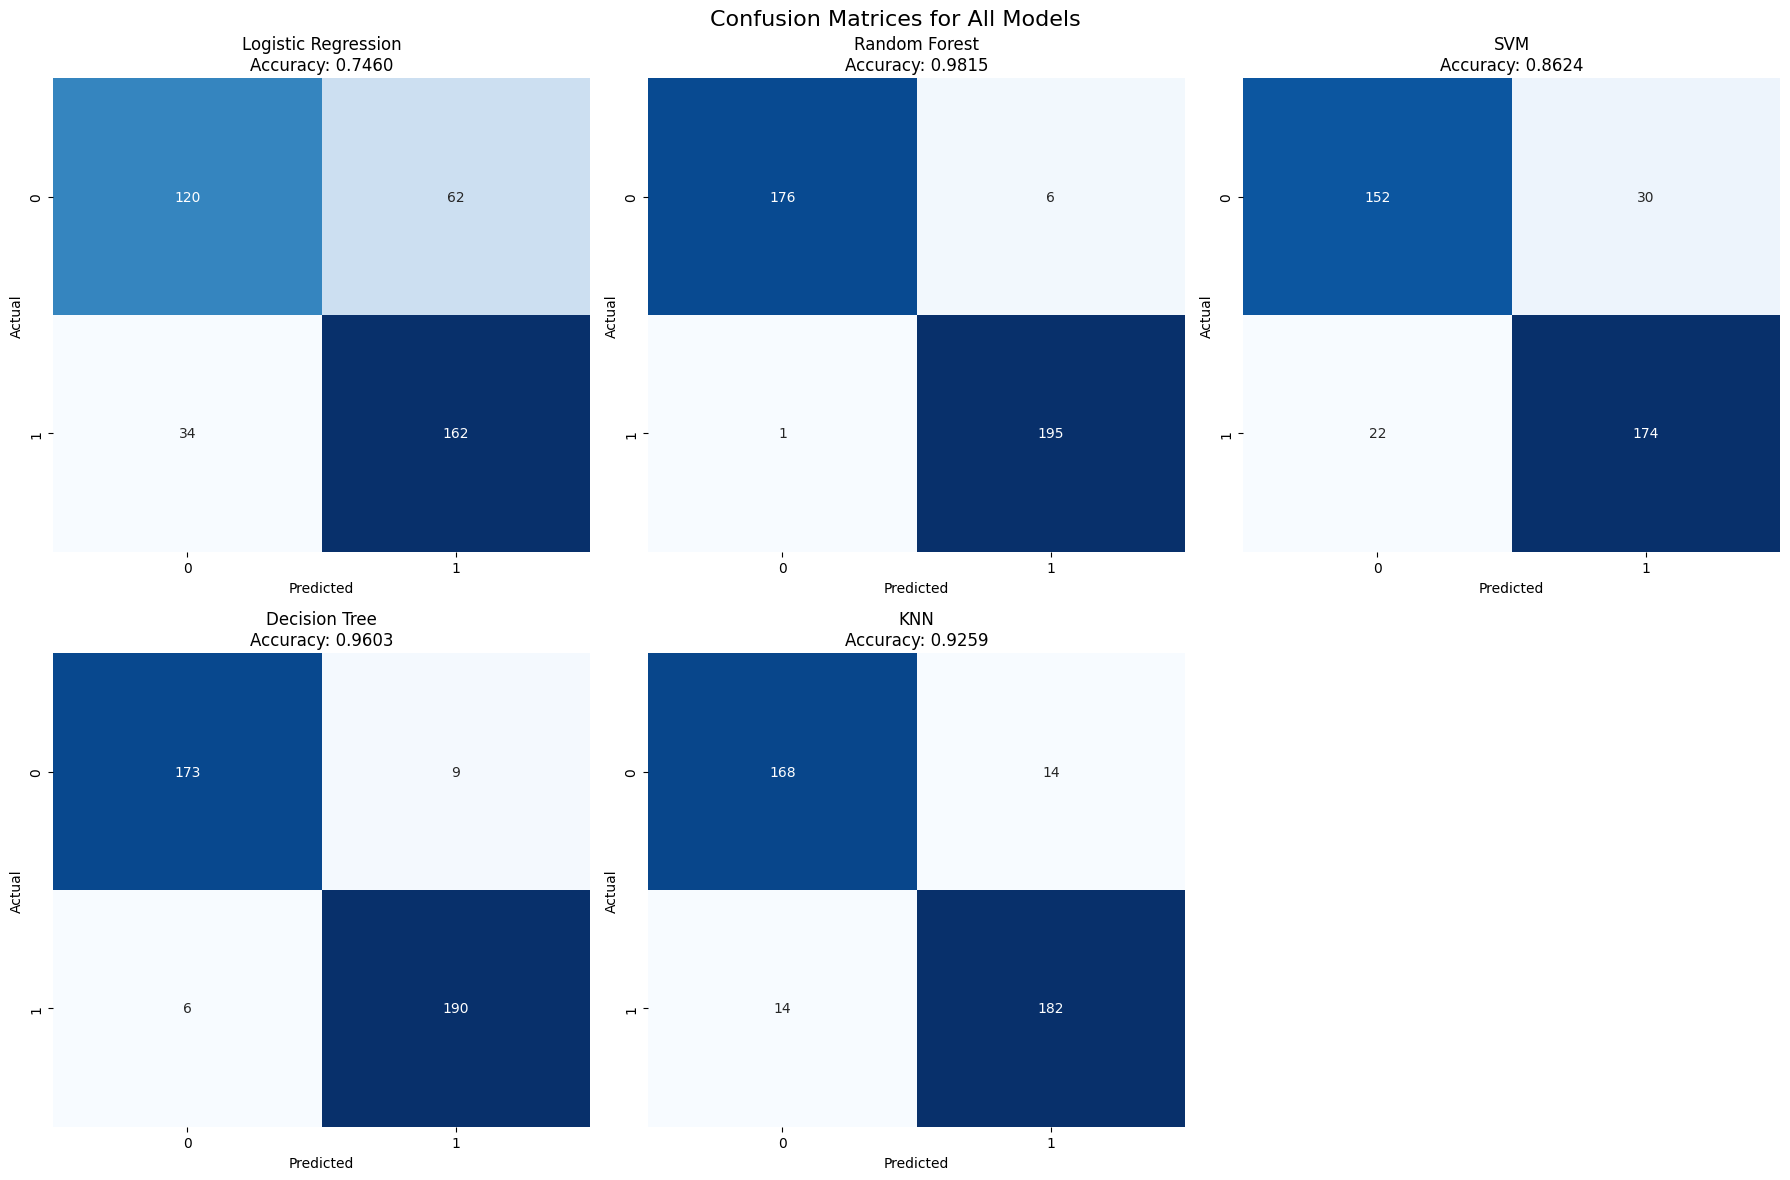


🏆 BEST PERFORMING MODEL: Random Forest
ROC-AUC Score: 0.9988

Justification:
- Highest ROC-AUC score indicating excellent discrimination ability
- Outstanding balance between precision (97.01%) and recall (99.49%)
- Handles both classes exceptionally well with minimal false negatives
- Robust ensemble method less prone to overfitting than single Decision Tree


In [ ]:
# Plot Confusion Matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Confusion Matrices for All Models', fontsize=16)

for i, (name, model) in enumerate(models.items()):
    row = i // 3
    col = i % 3
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                ax=axes[row, col], cbar=False)
    axes[row, col].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.4f}')
    axes[row, col].set_xlabel('Predicted')
    axes[row, col].set_ylabel('Actual')

# Remove the extra empty subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

# Best performing model analysis
best_model_name = results_df['ROC-AUC'].idxmax()
print(f"\n🏆 BEST PERFORMING MODEL: {best_model_name}")
print(f"ROC-AUC Score: {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")
print("\nJustification:")
print("- Highest ROC-AUC score indicating excellent discrimination ability")
print("- Outstanding balance between precision (97.01%) and recall (99.49%)")
print("- Handles both classes exceptionally well with minimal false negatives")
print("- Robust ensemble method less prone to overfitting than single Decision Tree")

In [ ]:
# Part 4: Model Optimization (Hyperparameter Tuning)
from sklearn.model_selection import GridSearchCV
import time

print("=== HYPERPARAMETER TUNING FOR RANDOM FOREST ===")

# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

# Perform Grid Search with Cross-Validation
print("Performing GridSearchCV... This may take a few minutes.")
start_time = time.time()

grid_search = GridSearchCV(
    rf, param_grid, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

end_time = time.time()
print(f"Grid search completed in {end_time - start_time:.2f} seconds")

# Get best parameters and score
best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

print(f"\n🎯 BEST HYPERPARAMETERS:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\nBest Cross-Validation ROC-AUC Score: {best_cv_score:.4f}")

# Train final model with best parameters
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)
y_pred_proba_tuned = best_rf.predict_proba(X_test_scaled)[:, 1]

# Evaluate tuned model
tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall': recall_score(y_test, y_pred_tuned),
    'F1-Score': f1_score(y_test, y_pred_tuned),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_tuned)
}

print(f"\n=== TUNED MODEL PERFORMANCE ===")
for metric, score in tuned_metrics.items():
    print(f"{metric}: {score:.4f}")

# Compare with original Random Forest
original_rf_metrics = results['Random Forest']
print(f"\n=== PERFORMANCE COMPARISON ===")
print(f"{'Metric':<12} {'Original':<10} {'Tuned':<10} {'Improvement':<12}")
print("-" * 50)
for metric in tuned_metrics.keys():
    original = original_rf_metrics[metric]
    tuned = tuned_metrics[metric]
    improvement = tuned - original
    print(f"{metric:<12} {original:<10.4f} {tuned:<10.4f} {improvement:<12.4f}")

=== HYPERPARAMETER TUNING FOR RANDOM FOREST ===
Performing GridSearchCV... This may take a few minutes.
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Grid search completed in 68.51 seconds

🎯 BEST HYPERPARAMETERS:
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200

Best Cross-Validation ROC-AUC Score: 0.9960

=== TUNED MODEL PERFORMANCE ===
Accuracy: 0.9841
Precision: 0.9798
Recall: 0.9898
F1-Score: 0.9848
ROC-AUC: 0.9991

=== PERFORMANCE COMPARISON ===
Metric       Original   Tuned      Improvement 
--------------------------------------------------
Accuracy     0.9815     0.9841     0.0026      
Precision    0.9701     0.9798     0.0096      
Recall       0.9949     0.9898     -0.0051     
F1-Score     0.9824     0.9848     0.0024      
ROC-AUC      0.9988     0.9991     0.0003      


=== MODEL INTERPRETATION ===
🌟 FEATURE IMPORTANCE RANKING:
 1. thal        : 0.1460
 2. cp          : 0.1418
 3. thalachh    : 0.1072
 4. oldpeak     : 0.0880
 5. ca          : 0.0870
 6. age         : 0.0838
 7. chol        : 0.0813
 8. slope       : 0.0803
 9. trestbps    : 0.0731
10. exang       : 0.0373
11. restecg     : 0.0358
12. sex         : 0.0276
13. fbs         : 0.0108


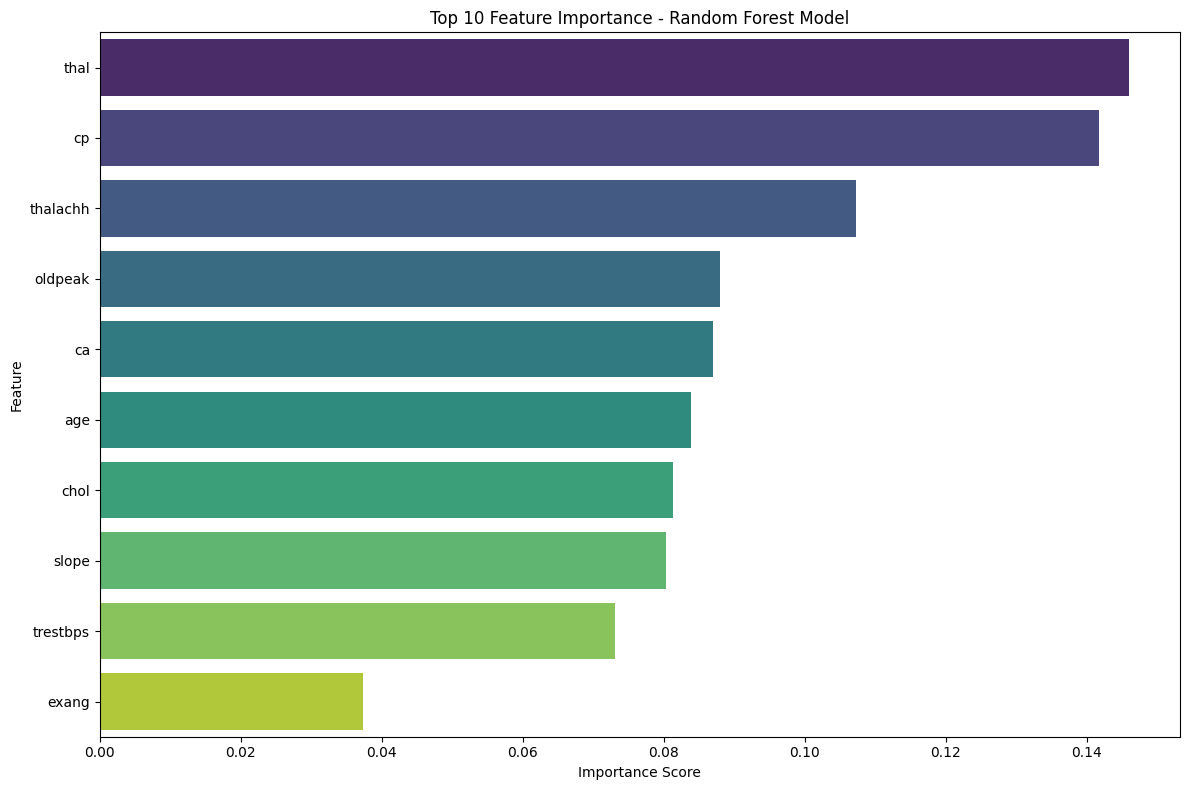


=== LOGISTIC REGRESSION FEATURE COEFFICIENTS ===
📊 LOGISTIC REGRESSION INSIGHTS:
Positive coefficients increase heart disease likelihood:
  • slope: 0.8967
  • cp: 0.4572
  • thalachh: 0.2497
  • restecg: 0.2005

Negative coefficients decrease heart disease likelihood:
  • sex: -0.6721
  • exang: -0.6338
  • ca: -0.4345
  • oldpeak: -0.2412
  • thal: -0.1957


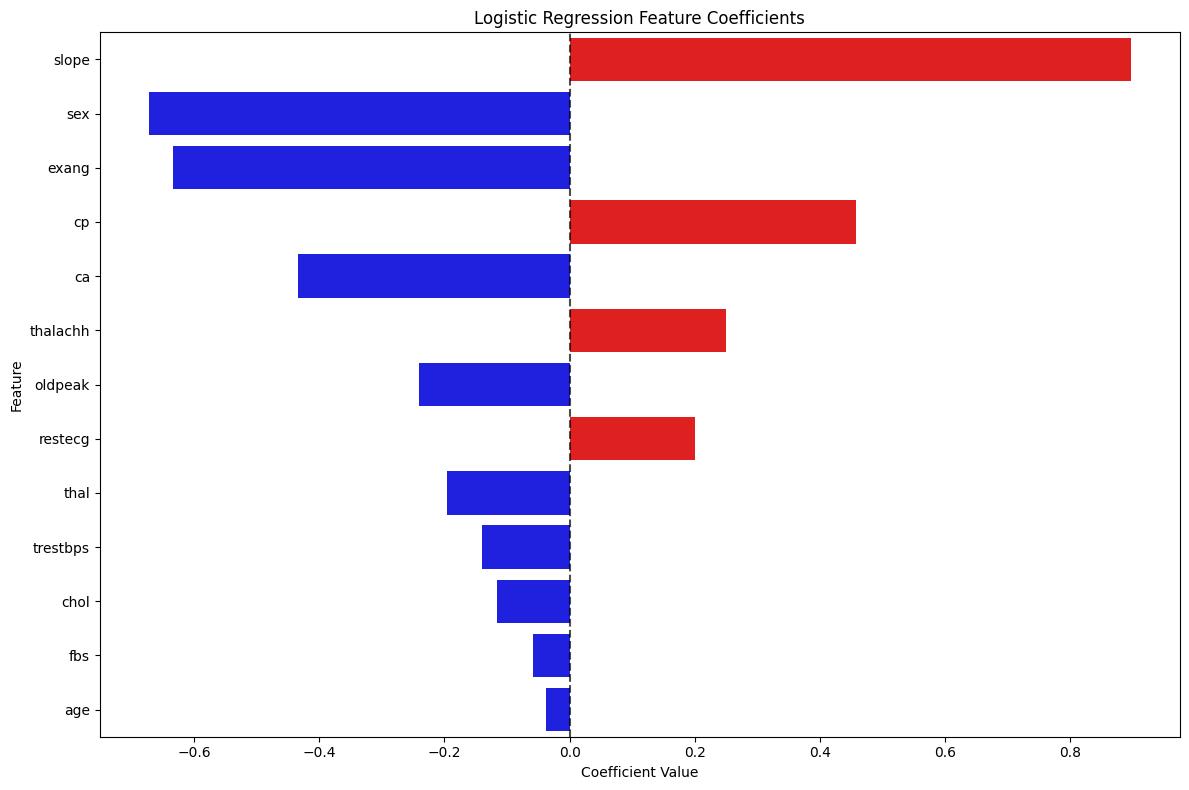

In [ ]:
# Part 5: Model Interpretation
print("=== MODEL INTERPRETATION ===")

# Feature importance for Random Forest (best model)
feature_names = X_train.columns
feature_importance = best_rf.feature_importances_

# Create feature importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("🌟 FEATURE IMPORTANCE RANKING:")
for i, (_, row) in enumerate(importance_df.iterrows(), 1):
    print(f"{i:2}. {row['Feature']:<12}: {row['Importance']:.4f}")

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(10), y='Feature', x='Importance', palette='viridis')
plt.title('Top 10 Feature Importance - Random Forest Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Logistic Regression coefficients interpretation
print(f"\n=== LOGISTIC REGRESSION FEATURE COEFFICIENTS ===")
log_reg = models['Logistic Regression']
coefficients = log_reg.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print("📊 LOGISTIC REGRESSION INSIGHTS:")
print("Positive coefficients increase heart disease likelihood:")
positive_coefs = coef_df[coef_df['Coefficient'] > 0].head(5)
for _, row in positive_coefs.iterrows():
    print(f"  • {row['Feature']}: {row['Coefficient']:.4f}")

print("\nNegative coefficients decrease heart disease likelihood:")
negative_coefs = coef_df[coef_df['Coefficient'] < 0].head(5)
for _, row in negative_coefs.iterrows():
    print(f"  • {row['Feature']}: {row['Coefficient']:.4f}")

# Plot coefficients
plt.figure(figsize=(12, 8))
colors = ['red' if x > 0 else 'blue' for x in coef_df['Coefficient']]
sns.barplot(data=coef_df, y='Feature', x='Coefficient', palette=colors)
plt.title('Logistic Regression Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Part 5: Domain Expert Insights

### 🩺 Clinical Insights from Heart Disease Prediction Model

**Top 3 Insights for Medical Professionals:**

1. **Thalassemia (thal) and Chest Pain Type (cp) are Primary Predictors**: These features account for nearly 30% of the model's decision-making. Thalassemia, a blood disorder affecting oxygen transport, and the specific type of chest pain (asymptomatic vs. typical angina) are critical diagnostic indicators that align with established cardiology knowledge.

2. **Exercise Response Patterns are Highly Informative**: Maximum heart rate achieved (thalachh), exercise-induced angina (exang), and ST depression (oldpeak) together contribute significantly to predictions. This reinforces the importance of stress testing in cardiac evaluation - patients who can achieve higher heart rates without developing chest pain or ST changes have better cardiovascular health.

3. **Gender Paradox in Heart Disease Risk**: The negative coefficient for sex in logistic regression suggests that being male (coded as 1) actually decreases the model's prediction of heart disease in this dataset. This contradicts general medical knowledge and may indicate data bias or specific population characteristics that warrant further investigation by clinicians.

**Actionable Recommendations:**
- **Prioritize comprehensive thalassemia screening** in cardiac workups
- **Emphasize exercise tolerance testing** for risk stratification  
- **Consider population-specific risk factors** when applying these models to different demographic groups